In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart-failure-prediction/heart.csv


In [2]:
df = pd.read_csv("/kaggle/input/heart-failure-prediction/heart.csv").copy()

In [3]:
df.head(5) # veriseti böyle gözüküyor

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.isnull().sum() # herhangi bir sütunda hiç null değer yok

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [5]:
df.info # 918 satır, 12 sütun varmış

<bound method DataFrame.info of      Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
0     40   M           ATA        140          289          0     Normal   
1     49   F           NAP        160          180          0     Normal   
2     37   M           ATA        130          283          0         ST   
3     48   F           ASY        138          214          0     Normal   
4     54   M           NAP        150          195          0     Normal   
..   ...  ..           ...        ...          ...        ...        ...   
913   45   M            TA        110          264          0     Normal   
914   68   M           ASY        144          193          1     Normal   
915   57   M           ASY        130          131          0     Normal   
916   57   F           ATA        130          236          0        LVH   
917   38   M           NAP        138          175          0     Normal   

     MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisea

In [6]:
df.dtypes 

# veritipleri bu şekildeymiş. Kategorik değişkenler olan 
# Sex, ChestPainType, RestingECG, ExerciseAngina, ve ST_Slope 
# değişkenlerini sayısal değerlerlere dönüştürmemiz gerekebilir

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [7]:
df.groupby("Sex").count() # 193 tane F, 725 tane M değerleri varmış

,Age,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
Sex,,,,,,,,,,,
F,193,193,193,193,193,193,193,193,193,193,193
M,725,725,725,725,725,725,725,725,725,725,725


In [8]:
df.groupby("ChestPainType").count()
# 496 tane ASY, 173 tane ATA, 203 tane NAP, 46 tane TA değerleri varmış

,Age,Sex,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
ChestPainType,,,,,,,,,,,
ASY,496,496,496,496,496,496,496,496,496,496,496
ATA,173,173,173,173,173,173,173,173,173,173,173
NAP,203,203,203,203,203,203,203,203,203,203,203
TA,46,46,46,46,46,46,46,46,46,46,46


In [9]:
df.groupby("RestingECG").count() # 188 tane LVH, 552 tane Normal, 178 tane ST varmış

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
RestingECG,,,,,,,,,,,
LVH,188,188,188,188,188,188,188,188,188,188,188
Normal,552,552,552,552,552,552,552,552,552,552,552
ST,178,178,178,178,178,178,178,178,178,178,178


In [10]:
df.groupby("ExerciseAngina").count() # 547 tane N, 371 tane Y değerleri varmış

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,Oldpeak,ST_Slope,HeartDisease
ExerciseAngina,,,,,,,,,,,
N,547,547,547,547,547,547,547,547,547,547,547
Y,371,371,371,371,371,371,371,371,371,371,371


In [11]:
df.groupby("ST_Slope").count() # 63 tane Down, 460 tane Flat, 395 tane Up değerleri varmış

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,HeartDisease
ST_Slope,,,,,,,,,,,
Down,63,63,63,63,63,63,63,63,63,63,63
Flat,460,460,460,460,460,460,460,460,460,460,460
Up,395,395,395,395,395,395,395,395,395,395,395


Kategorik değişkenleri sayısal değerlere dönüştürmek istiyorsak, burada kullanabileceğimiz bazı metrikler var: **Label Encoding** ve **One-Hot Encoding** .

Eğer kategorik değişken **binary(ikili) sınıflı** ise onehot mu label mı fark etmiyor, ancak bu durumda **Label Encoding** yaygın olarak kullanılır.

Eğer kategorik değişken **ikiden fazla sınıflı** ise ve sınıflar arasında **sıralama (büyüklük-küçüklük) var** ise **Label Encoding kullanılır**.

Eğer kategorik değişken **ikiden fazla sınıflı** ise ve sınıflar arasında **sıralama yoksa** **One-Hot Encoding** tercih edilir.

In [12]:
from sklearn.preprocessing import LabelEncoder

lbe = LabelEncoder()
df["Sex"] = lbe.fit_transform(df["Sex"])

df.head(5)

# Bir kategorik sınıf olan Sex, binary değerler(M ve F) içerdiği için 
# kategorik - sayısal dönüşümünü label encoder kullanarak gerçekleştirdik 

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,0,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,1,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,0,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,1,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [13]:
df = pd.get_dummies(df, columns = ["ChestPainType"], prefix = "ChestPainType", dtype = int,drop_first = True)

df.head(5)

# Bir kategorik sınıf olan ChestPainType, ikiden fazla sınıf içerdiği ve Nominal(sıralama yok) olduğu için
# One-Hot Encoding yöntemi ile kategorikten sayısala çevireceğiz

,Age,Sex,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA
0,40,1,140,289,0,Normal,172,N,0.0,Up,0,1,0,0
1,49,0,160,180,0,Normal,156,N,1.0,Flat,1,0,1,0
2,37,1,130,283,0,ST,98,N,0.0,Up,0,1,0,0
3,48,0,138,214,0,Normal,108,Y,1.5,Flat,1,0,0,0
4,54,1,150,195,0,Normal,122,N,0.0,Up,0,0,1,0


In [14]:
df = pd.get_dummies(df, columns=["RestingECG"], prefix="RestingECG", dtype= int, drop_first=True)

df.head(5)

# Bir kategorik sınıf olan RestingECG, ikiden fazla sınıf içerdiği ve Nominal(sıralama yok) olduğu için
# One-Hot Encoding yöntemi ile kategorikten sayısala çevireceğiz

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST
0,40,1,140,289,0,172,N,0.0,Up,0,1,0,0,1,0
1,49,0,160,180,0,156,N,1.0,Flat,1,0,1,0,1,0
2,37,1,130,283,0,98,N,0.0,Up,0,1,0,0,0,1
3,48,0,138,214,0,108,Y,1.5,Flat,1,0,0,0,1,0
4,54,1,150,195,0,122,N,0.0,Up,0,0,1,0,1,0


In [15]:
lbe = LabelEncoder()

df["ExerciseAngina"] = lbe.fit_transform(df["ExerciseAngina"])

df.head(5)

# Bir kategorik sınıf olan ExerciseAngina, binary değerler(N ve Y) içerdiği için 
# kategorik - sayısal dönüşümünü label encoder kullanarak gerçekleştirdik 

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST
0,40,1,140,289,0,172,0,0.0,Up,0,1,0,0,1,0
1,49,0,160,180,0,156,0,1.0,Flat,1,0,1,0,1,0
2,37,1,130,283,0,98,0,0.0,Up,0,1,0,0,0,1
3,48,0,138,214,0,108,1,1.5,Flat,1,0,0,0,1,0
4,54,1,150,195,0,122,0,0.0,Up,0,0,1,0,1,0


In [16]:
slope_mapping = {
    "Down": 1, 
    "Flat": 2, 
    "Up": 3
}
df["ST_Slope"] = df["ST_Slope"].map(slope_mapping)

df.head(5)

# Bir kategorik sınıf olan ST_Slope, ikiden fazla sınıf içerdiği ve Ordinal(sıralama var) olduğu için
# Ne One-Hot Encoding yöntemi ne de Label Encoding ile çevirme yapacağız
# Değerlerin sıralaması olduğu için mapleyerek kendimiz manuel değerler gireceğiz
# bunu da bu şekilde ordinal çevrimlerde mapping ile yaparız

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST
0,40,1,140,289,0,172,0,0.0,3,0,1,0,0,1,0
1,49,0,160,180,0,156,0,1.0,2,1,0,1,0,1,0
2,37,1,130,283,0,98,0,0.0,3,0,1,0,0,0,1
3,48,0,138,214,0,108,1,1.5,2,1,0,0,0,1,0
4,54,1,150,195,0,122,0,0.0,3,0,0,1,0,1,0


In [17]:
"""

Bu tabloya bakarak yapabileceğimiz yorumlar:

RestingBP
min,  0.0,    MANTIKSIZ (VERİ HATASI): Bir insanın sistolik kan basıncının 0 olması mümkün değildir. Bu, büyük olasılıkla veriyi toplayan kişinin bilinmeyen/eksik değeri 0 ile doldurduğu anlamına gelir.
max,  200.0,  OLASI AYKIRI DEĞER: 200 mmHg çok yüksek bir kan basıncıdır (Hipertansif Kriz seviyesi). Aykırı değer olabilir, ancak teknik olarak mümkündür."

Cholesterol
min,  0.0,    MANTIKSIZ (VERİ HATASI): Canlı bir insanın kolesterol seviyesinin 0 olması biyolojik olarak mümkün değildir. Bu da büyük olasılıkla eksik/kayıp veri göstergesidir.
max,  603.0,  AYKIRI DEĞER: 603 mg/dl oldukça ekstrem bir kolesterol seviyesidir. Bu, potansiyel bir aykırı değerdir ve modelimizi bozabilir.

"""
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
Sex,918.0,0.789760,0.407701,0.0,1.00,1.0,1.0,1.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
ExerciseAngina,918.0,0.404139,0.490992,0.0,0.00,0.0,1.0,1.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
ST_Slope,918.0,2.361656,0.607056,1.0,2.00,2.0,3.0,3.0
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [18]:
df[df["RestingBP"]<20] # mantıksız aralıkta sadece 1 adet veri olduğundan dolayı silebiliriz

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST
449,55,1,0,0,0,155,0,1.5,2,1,0,1,0,1,0


In [19]:
df = df[df["RestingBP"]>20] # 20'den büyük olanları al sadece dedik

In [20]:
df[df["Cholesterol"]==0] 
# mantıksız aralıkta 172 adet, verisetinin yaklaşık %20'si kadar veri olduğundan silmemeli, 
# başka bir şey düşünmeliyiz

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST
293,65,1,115,0,0,93,1,0.0,2,1,0,0,0,1,0
294,32,1,95,0,1,127,0,0.7,3,1,0,0,1,1,0
295,61,1,105,0,1,110,1,1.5,3,1,0,0,0,1,0
296,50,1,145,0,1,139,1,0.7,2,1,0,0,0,1,0
297,57,1,110,0,1,131,1,1.4,3,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
514,43,1,122,0,0,120,0,0.5,3,1,0,0,0,1,0
515,63,1,130,0,1,160,0,3.0,2,0,0,1,0,0,1
518,48,1,102,0,1,110,1,1.0,1,1,0,1,0,0,1
535,56,1,130,0,0,122,1,1.0,2,1,0,0,0,0,0


In [21]:
# şu anda kolesterolü 0 olan bireylere odaklanacağız. böyle bir şey mümkün olamayacağından dolayı onlara ne yapacağımıza karar vermeden önce gözlemleyeceğiz

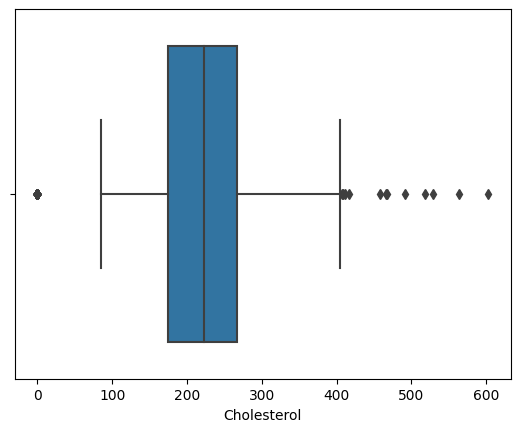

In [22]:
import seaborn as sns

df_kolesterol = df["Cholesterol"]

sns.boxplot(x=df_kolesterol); 

In [23]:
df["Cholesterol"] = df["Cholesterol"].replace(0, df["Cholesterol"].median()) 

# Cholesterol'ü sıfır olan tüm Cholesterol sütunundaki satırları medianı ile değiştirdik. artık Cholesterol=0 olan yok

In [24]:
"""
MinMaxScaler ölçeklendirmesini, model kurulumu aşamasından hemen önce yapmalıyız. 
Bu, farklı aralıklardaki tüm sayısal verileri 0 ile 1 arasına sıkıştırarak, büyük özelliklerin (Kolesterol) 
küçük özelliklere (Oldpeak) haksız yere baskın gelmesini engeller.
Sonuç olarak, bu işlem modelimizin eğitimini hızlandırır ve daha kararlı sonuçlar elde etmemizi sağlar.
"""

from sklearn.preprocessing import MinMaxScaler
import pandas as pd # Bu zaten yüklü

# Ölçeklenecek sayısal sütunlar listesi
# Bu liste, kategorik olmayan tüm orijinal sütunlardır.
numerical_features = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

# MinMaxScaler'ı tanımla
scaler = MinMaxScaler()

# Seçilen sütunları ölçekle, hem fit et (öğren) hem de transform et (dönüştür) ve df'e ata
df[numerical_features] = scaler.fit_transform(df[numerical_features])

# Kontrol: İlk 5 satırı yazdır
print(df[numerical_features].head())

        Age  RestingBP  Cholesterol     MaxHR   Oldpeak
0  0.244898   0.500000     0.393822  0.788732  0.295455
1  0.428571   0.666667     0.183398  0.676056  0.409091
2  0.183673   0.416667     0.382239  0.267606  0.295455
3  0.408163   0.483333     0.249035  0.338028  0.465909
4  0.530612   0.583333     0.212355  0.436620  0.295455


# Model Kurulumu

In [25]:
Y = df["HeartDisease"]

In [26]:
X = df.drop('HeartDisease', axis=1)

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.15, random_state=42)

In [28]:
from sklearn import linear_model

logreg = linear_model.LogisticRegression(random_state = 42, max_iter= 150) # modeli kurma

# Önemli: Bütün .T (transpoze) işlemleri kaldırıldı.
print("Test Accuracy: {} ".format(logreg.fit(X_train, Y_train).score(X_test, Y_test))) # modeli fit ettikten sonra test skorunu alma
print("Train Accuracy: {} ".format(logreg.fit(X_train, Y_train).score(X_train, Y_train))) # modeli fit ettikten sonra train skorunu alma

Test Accuracy: 0.8333333333333334 
Train Accuracy: 0.8549422336328626 
